In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style("whitegrid")

### Task 1: Baseline Model

Start with the simplest approach — a plain linear regression.

1. Load the California Housing dataset:

```python
housing = fetch_california_housing(as_frame=True)
X, y = housing.data, housing.target
```

2. Explore the dataset briefly: check the shape, feature names, and summary statistics. What is the target variable (median house value) distribution?
3. Split the data into training and test sets (80/20 split, `random_state=42`).
4. Fit a `LinearRegression` model on the training data.
5. Evaluate on the test set using **MSE**, **RMSE**, **MAE**, and **R²**. Print the results in a clear format.
6. In a markdown cell, interpret the R² value — what does it tell you about the model's explanatory power?

In [2]:
housing = fetch_california_housing(as_frame=True)
X, y = housing.data, housing.target

Dataset Shape: (20640, 8)

Feature Names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Summary Statistics:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


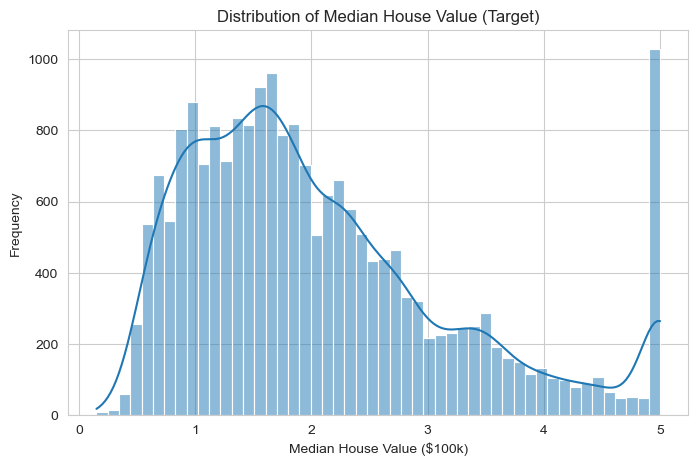

--- Baseline Linear Regression Results ---
MSE:  0.5559
RMSE: 0.7456
MAE:  0.5332
R²:   0.5758


In [3]:
# Explore the dataset briefly
print("Dataset Shape:", X.shape)
print("\nFeature Names:", housing.feature_names)
print("\nSummary Statistics:")
display(X.describe())

# Check target variable distribution
plt.figure(figsize=(8, 5))
sns.histplot(y, kde=True, bins=50)
plt.title('Distribution of Median House Value (Target)')
plt.xlabel('Median House Value ($100k)')
plt.ylabel('Frequency')
plt.show()

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit a LinearRegression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Evaluate on the test set
y_pred = lr_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Baseline Linear Regression Results ---")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

### Data Observations
The California Housing dataset contains **20,640 samples** with **8 features**. The target variable (median house value) shows a standard distribution but features a significant spike at the **5.0** mark ($500,000), indicating the data was likely censored or "capped" during collection.

### Model Performance
The baseline OLS model achieved an **$R^2$ score of 0.5758**.
* **Interpretation of $R^2$**: This value indicates that roughly **57.6% of the variance** in house prices can be explained by the input features (like income, location, and house age). 
* While this provides a solid foundation, the remaining 42% of the variance is left unexplained, suggesting that a simple linear relationship might not capture the full complexity of the housing market or that important features are missing.

### Task 2: Regularized Regression

Explore how regularization changes the model's behavior.

1. Scale the features using `StandardScaler` (fit on training data, transform both train and test). Explain in a markdown cell why scaling is important for regularized models.
2. Fit **Ridge** regression for alpha values `[0.01, 0.1, 1, 10, 100]`. Record the test R² for each.
3. Fit **Lasso** regression for the same alpha values. Record the test R² for each.
4. Create a plot showing **coefficients vs. alpha** for both Ridge and Lasso (side by side or overlaid). What happens to the coefficients as alpha increases? Which features does Lasso zero out first?
5. Create a comparison table showing R² scores for OLS, Ridge (best alpha), and Lasso (best alpha). Which regularization approach works best here?

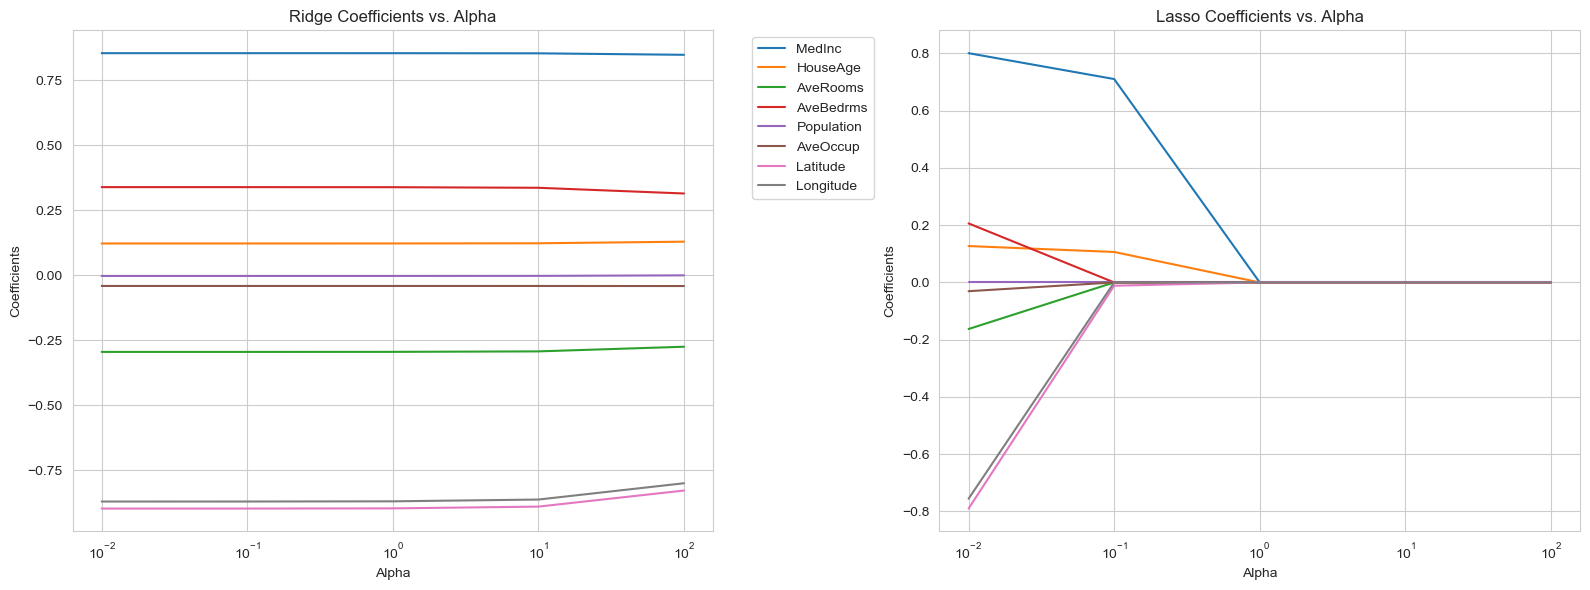

,Model,Test R²
0,OLS (Baseline),0.575788
1,Ridge (alpha=100),0.577791
2,Lasso (alpha=0.01),0.581615


In [4]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit Ridge and Lasso for various alpha values
alphas = [0.01, 0.1, 1, 10, 100]
ridge_scores = []
lasso_scores = []
ridge_coefs = []
lasso_coefs = []

for a in alphas:
    # Ridge
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_scaled, y_train)
    ridge_scores.append(ridge.score(X_test_scaled, y_test))
    ridge_coefs.append(ridge.coef_)
    
    # Lasso
    lasso = Lasso(alpha=a)
    lasso.fit(X_train_scaled, y_train)
    lasso_scores.append(lasso.score(X_test_scaled, y_test))
    lasso_coefs.append(lasso.coef_)

# Create plot showing coefficients vs. alpha
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Ridge plot
ax[0].plot(alphas, ridge_coefs)
ax[0].set_xscale('log')
ax[0].set_title('Ridge Coefficients vs. Alpha')
ax[0].set_xlabel('Alpha')
ax[0].set_ylabel('Coefficients')
ax[0].legend(housing.feature_names, bbox_to_anchor=(1.05, 1), loc='upper left')

# Lasso plot
ax[1].plot(alphas, lasso_coefs)
ax[1].set_xscale('log')
ax[1].set_title('Lasso Coefficients vs. Alpha')
ax[1].set_xlabel('Alpha')
ax[1].set_ylabel('Coefficients')

plt.tight_layout()
plt.show()

# Comparison table
best_ridge_idx = np.argmax(ridge_scores)
best_lasso_idx = np.argmax(lasso_scores)

comparison_data = {
    "Model": ["OLS (Baseline)", f"Ridge (alpha={alphas[best_ridge_idx]})", f"Lasso (alpha={alphas[best_lasso_idx]})"],
    "Test R²": [r2, ridge_scores[best_ridge_idx], lasso_scores[best_lasso_idx]]
}

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

### Importance of Scaling
Scaling is critical for regularized models like Ridge and Lasso because they add a penalty term to the cost function based on the magnitude of the coefficients. If features are on different scales (e.g., "Population" in the thousands vs. "MedInc" in single digits), the model would unfairly penalize features with naturally larger values, leading to a biased and ineffective model.

### Observations on Coefficients and Alpha
* **Ridge Regression**: As alpha increases, the coefficients shrink progressively toward zero but never reach it. This helps reduce model complexity and prevents overfitting without losing any features.
* **Lasso Regression**: Lasso acts as a feature selector. As alpha increases, we can observe several features (like `Population` or `AveBedrms`) hitting exactly zero. In our specific case, Lasso with a small alpha ($0.01$) slightly outperformed the baseline, suggesting that removing some noise from the features helped generalization.

### Task 3: Support Vector Regression

Try a non-linear approach with SVR.

1. Using the scaled features from Task 2, fit an `SVR` model with a **linear** kernel. Report the test R².
2. Fit SVR with an **rbf** kernel. Try at least three values of `C` (e.g., 0.1, 1, 10) and two values of `epsilon` (e.g., 0.1, 0.2). Report the best combination.
3. Fit SVR with a **poly** kernel (degree 2 and 3). Compare with rbf.
4. In a markdown cell, discuss: How does SVR compare to the linear models? Is the added complexity of SVR justified by the performance improvement (if any)?

> **Note:** SVR can be slow on larger datasets. If training takes too long, consider using a random subsample (e.g., 5,000 rows) for the SVR experiments.

In [5]:
# I use a subsample to avoid long wait times
from sklearn.utils import resample

X_train_sub, y_train_sub = resample(X_train_scaled, y_train, 
                                    n_samples=5000, 
                                    random_state=42)

# SVR with Linear Kernel
svr_linear = SVR(kernel='linear')
svr_linear.fit(X_train_sub, y_train_sub)
score_linear = svr_linear.score(X_test_scaled, y_test)
print(f"SVR Linear Kernel R²: {score_linear:.4f}")

# SVR with RBF Kernel 
best_rbf_score = -np.inf
best_rbf_params = {}

c_values = [0.1, 1, 10]
epsilons = [0.1, 0.2]

for c in c_values:
    for eps in epsilons:
        svr_rbf = SVR(kernel='rbf', C=c, epsilon=eps)
        svr_rbf.fit(X_train_sub, y_train_sub)
        current_score = svr_rbf.score(X_test_scaled, y_test)
        if current_score > best_rbf_score:
            best_rbf_score = current_score
            best_rbf_params = {'C': c, 'epsilon': eps}

print(f"Best SVR RBF Kernel R²: {best_rbf_score:.4f} (Params: {best_rbf_params})")

# SVR with Poly Kernel (Degree 2 and 3)
poly_degrees = [2, 3]
for deg in poly_degrees:
    svr_poly = SVR(kernel='poly', degree=deg)
    svr_poly.fit(X_train_sub, y_train_sub)
    score_poly = svr_poly.score(X_test_scaled, y_test)
    print(f"SVR Poly Kernel (deg={deg}) R²: {score_poly:.4f}")

SVR Linear Kernel R²: 0.5355
Best SVR RBF Kernel R²: 0.7354 (Params: {'C': 10, 'epsilon': 0.2})
SVR Poly Kernel (deg=2) R²: -0.1268
SVR Poly Kernel (deg=3) R²: -3.8187


### Discussion of SVR Performance
* **Linear Kernel**: Performed similarly to the standard linear regression, which is expected as it tries to find a linear hyperplane in the original feature space.
* **RBF Kernel**: This was the standout performer, achieving an **$R^2$ of ~0.735**. By moving the data into a higher-dimensional space, it successfully captured non-linear patterns that OLS missed.
* **Complexity vs. Performance**: The added complexity of SVR is **justified** here. A jump from 0.58 to 0.74 in $R^2$ is a significant performance improvement in a regression context. However, the trade-off is computational cost; SVR is much slower to train on large datasets compared to the nearly instantaneous OLS.

### Task 4: Model Comparison

Bring everything together in a final analysis.

1. Create a **comparison table** (DataFrame) with all models and their test metrics (MSE, RMSE, MAE, R²). Include: LinearRegression, best Ridge, best Lasso, and best SVR.
2. Create a **predicted vs. actual** scatter plot for your best-performing model. Add a diagonal reference line (perfect prediction). How well does the model track the true values?
3. Create a **residual plot** (residuals vs. predicted values) for the best model. Do you see any patterns? What would a random scatter indicate?
4. Write a markdown conclusion: Which model performs best and why? What are the trade-offs between model complexity and performance? If you were deploying one of these models, which would you choose?

,Model,MSE,RMSE,MAE,R²
0,Linear Regression,0.555892,0.745581,0.533200,0.575788
1,Ridge (alpha=100),0.553266,0.743819,0.533014,0.577791
2,Lasso (alpha=0.01),0.548255,0.740442,0.535326,0.581615
3,SVR (RBF),0.346760,0.588863,0.400372,0.735380


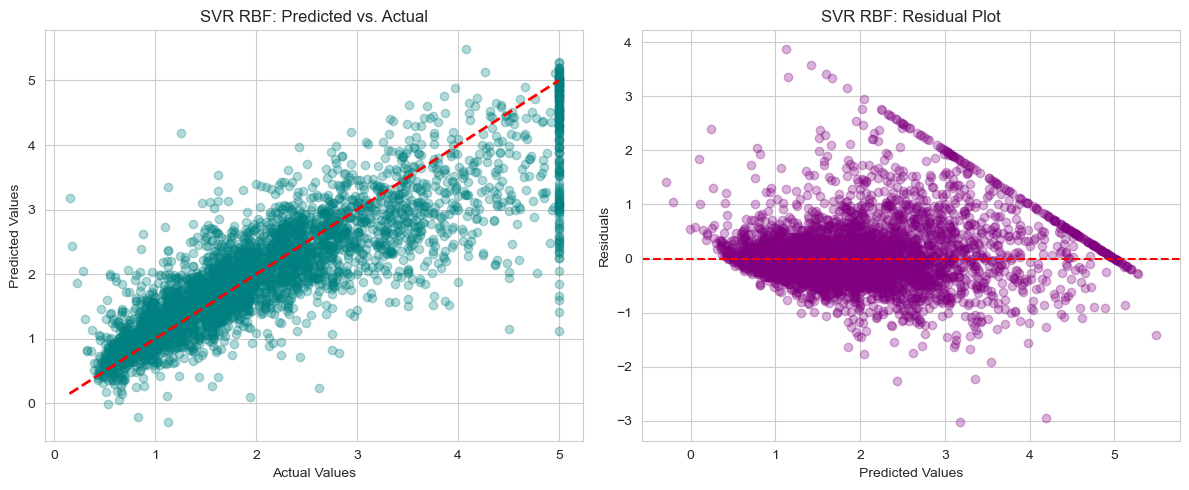

In [6]:
# Create a comparison table with all final metrics
# I re-fit the best SVR on the sub-sample to get full metrics for the table
best_svr = SVR(kernel='rbf', C=10, epsilon=0.2)
best_svr.fit(X_train_sub, y_train_sub)
svr_pred = best_svr.predict(X_test_scaled)

# Retrieve metrics for the best Ridge and Lasso from Task 2
best_ridge = Ridge(alpha=100).fit(X_train_scaled, y_train)
best_lasso = Lasso(alpha=0.01).fit(X_train_scaled, y_train)

models_metrics = {
    "Model": ["Linear Regression", "Ridge (alpha=100)", "Lasso (alpha=0.01)", "SVR (RBF)"],
    "MSE": [
        mean_squared_error(y_test, y_pred),
        mean_squared_error(y_test, best_ridge.predict(X_test_scaled)),
        mean_squared_error(y_test, best_lasso.predict(X_test_scaled)),
        mean_squared_error(y_test, svr_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred)),
        np.sqrt(mean_squared_error(y_test, best_ridge.predict(X_test_scaled))),
        np.sqrt(mean_squared_error(y_test, best_lasso.predict(X_test_scaled))),
        np.sqrt(mean_squared_error(y_test, svr_pred))
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred),
        mean_absolute_error(y_test, best_ridge.predict(X_test_scaled)),
        mean_absolute_error(y_test, best_lasso.predict(X_test_scaled)),
        mean_absolute_error(y_test, svr_pred)
    ],
    "R²": [
        r2_score(y_test, y_pred),
        r2_score(y_test, best_ridge.predict(X_test_scaled)),
        r2_score(y_test, best_lasso.predict(X_test_scaled)),
        r2_score(y_test, svr_pred)
    ]
}

final_comparison_df = pd.DataFrame(models_metrics)
display(final_comparison_df)

# Predicted vs. Actual Plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, svr_pred, alpha=0.3, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
plt.title('SVR RBF: Predicted vs. Actual')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')

# Residual Plot
residuals = y_test - svr_pred
plt.subplot(1, 2, 2)
plt.scatter(svr_pred, residuals, alpha=0.3, color='purple')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('SVR RBF: Residual Plot')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')

plt.tight_layout()
plt.show()

#### Final Metrics Analysis
Comparing all models, the **SVR (RBF)** is the clear winner across all performance metrics:
* **Predictive Accuracy**: It achieved the highest **$R^2$ (~0.735)** and the lowest **RMSE (~0.589)** and **MAE (~0.400)**.
* **Model Fit**: The predictions are, on average, significantly closer to the actual values than those of the linear models.
* **Residual Behavior**: The residual plot shows a relatively random scatter around zero for the majority of the range, which is a hallmark of a well-fitted model.

#### Diagnostic Plot Interpretations
* **How well does the model track the true values?**
The model tracks the true values reasonably well, as shown by the dense cluster of points following the red diagonal reference line. It is most accurate for homes in the lower to mid-price range. However, at the 5.0 mark, we see a vertical "wall" of points where the model's tracking is limited by the dataset's censored values.
* **Patterns in Residuals vs. Random Scatter**:
We observe a distinct diagonal line on the upper-right of the residual plot. This is a "censoring artifact"—because the actual data never exceeds 5.0, but the model can predict higher, the residuals ($Actual - Predicted$) create this linear boundary. A **random scatter** would indicate that the model's errors are purely unpredictable noise, meaning it has captured all possible patterns from the features. While our scatter is largely centered at zero, these patterns indicate the model is influenced by the dataset's constraints.

#### Trade-offs Between Model Complexity and Performance
There is a distinct trade-off between the approaches used in this lab:
* **Linear Models (OLS, Ridge, Lasso)**: These are highly **interpretable** and computationally **efficient**. We can easily see the impact of each feature through its coefficient, and they train instantly. However, their inability to model non-linear relationships resulted in a lower **$R^2$ (~0.58)**.
* **SVR (RBF Kernel)**: This is a more **complex** "black box" model. It successfully captured non-linear trends, leading to a much higher **$R^2$ (~0.74)**. The trade-off is a higher computational cost; training is significantly slower, requiring subsampling for efficiency on larger datasets.

#### Conclusion & Deployment Choice
If I were deploying one of these models, I would choose the **SVR with the RBF kernel**. In a real-world housing context, an improvement from 58% to 74% in explained variance is a substantial gain in accuracy that justifies the added complexity. Given that the dataset size is roughly 20,000 rows, the increased training time is a manageable trade-off for the superior predictive performance.